##### Copyright 2019 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Deep Convolutional Generative Adversarial Network

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/generative/dcgan">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/generative/dcgan.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/dcgan.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/generative/dcgan.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This tutorial demonstrates how to generate images of handwritten digits using a [Deep Convolutional Generative Adversarial Network](https://arxiv.org/pdf/1511.06434.pdf) (DCGAN). The code is written using the [Keras Sequential API](https://www.tensorflow.org/guide/keras) with a `tf.GradientTape` training loop.

## What are GANs?
[Generative Adversarial Networks](https://arxiv.org/abs/1406.2661) (GANs) are one of the most interesting ideas in computer science today. Two models are trained simultaneously by an adversarial process. A *generator* ("the artist") learns to create images that look real, while a *discriminator* ("the art critic") learns to tell real images apart from fakes.

![A diagram of a generator and discriminator](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gan1.png?raw=1)

During training, the *generator* progressively becomes better at creating images that look real, while the *discriminator* becomes better at telling them apart. The process reaches equilibrium when the *discriminator* can no longer distinguish real images from fakes.

![A second diagram of a generator and discriminator](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/images/gan2.png?raw=1)

This notebook demonstrates this process on the MNIST dataset. The following animation shows a series of images produced by the *generator* as it was trained for 50 epochs. The images begin as random noise, and increasingly resemble hand written digits over time.

![sample output](https://tensorflow.org/images/gan/dcgan.gif)

To learn more about GANs, see MIT's [Intro to Deep Learning](http://introtodeeplearning.com/) course.

### Setup

In [2]:
import tensorflow as tf

In [3]:
tf.__version__

'2.20.0'

In [4]:
# To generate GIFs
!pip install imageio
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-2p2ong2f
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-2p2ong2f
  Resolved https://github.com/tensorflow/docs to commit 0054afff57cd4a4ea5389088a89942603461ee6f
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.5.12.61975-py3-none-any.whl size=186932 sha256=58913f39882bc6eff763e2224e893c3b42bddc3fcb68a33a8970cd86f33edc0d
  Stored in directory: /tmp/pip-ephem-wheel-cache-ygeox8hi/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs


In [5]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

### Load and prepare the dataset

You will use the MNIST dataset to train the generator and the discriminator. The generator will generate handwritten digits resembling the MNIST data.

In [6]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]

In [8]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [9]:
# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## Create the models

Both the generator and discriminator are defined using the [Keras Sequential API](https://www.tensorflow.org/guide/keras#sequential_model).

### The Generator

The generator uses `tf.keras.layers.Conv2DTranspose` (upsampling) layers to produce an image from a seed (random noise). Start with a `Dense` layer that takes this seed as input, then upsample several times until you reach the desired image size of 28x28x1. Notice the `tf.keras.layers.LeakyReLU` activation for each layer, except the output layer which uses tanh.

In [36]:
def make_generator_model(noise_dim=100):
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

Use the (as yet untrained) generator to create an image.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


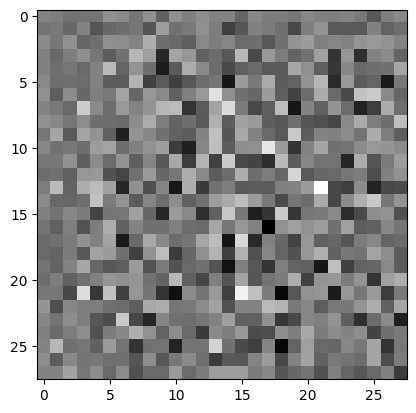

In [11]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

### The Discriminator

The discriminator is a CNN-based image classifier.

In [12]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                                     input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

Use the (as yet untrained) discriminator to classify the generated images as real or fake. The model will be trained to output positive values for real images, and negative values for fake images.

In [13]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[0.0004864]], shape=(1, 1), dtype=float32)


## Define the loss and optimizers

Define loss functions and optimizers for both models.


In [14]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

### Discriminator loss

This method quantifies how well the discriminator is able to distinguish real images from fakes. It compares the discriminator's predictions on real images to an array of 1s, and the discriminator's predictions on fake (generated) images to an array of 0s.

In [15]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

### Generator loss
The generator's loss quantifies how well it was able to trick the discriminator. Intuitively, if the generator is performing well, the discriminator will classify the fake images as real (or 1). Here, compare the discriminators decisions on the generated images to an array of 1s.

In [16]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

The discriminator and the generator optimizers are different since you will train two networks separately.

In [17]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

### Save checkpoints
This notebook also demonstrates how to save and restore models, which can be helpful in case a long running training task is interrupted.

In [18]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Define the training loop


In [19]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

The training loop begins with generator receiving a random seed as input. That seed is used to produce an image. The discriminator is then used to classify real images (drawn from the training set) and fakes images (produced by the generator). The loss is calculated for each of these models, and the gradients are used to update the generator and discriminator.

In [20]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [21]:
def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for image_batch in dataset:
      train_step(image_batch)

    # Produce images for the GIF as you go
    display.clear_output(wait=True)
    generate_and_save_images(generator,
                             epoch + 1,
                             seed)

    # Save the model every 15 epochs
    if (epoch + 1) % 15 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)

    print ('Time for epoch {} is {} sec'.format(epoch + 1, time.time()-start))

  # Generate after the final epoch
  display.clear_output(wait=True)
  generate_and_save_images(generator,
                           epochs,
                           seed)

**Generate and save images**


In [22]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
  predictions = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(predictions.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
  plt.show()

## Train the model
Call the `train()` method defined above to train the generator and discriminator simultaneously. Note, training GANs can be tricky. It's important that the generator and discriminator do not overpower each other (e.g., that they train at a similar rate).

At the beginning of the training, the generated images look like random noise. As training progresses, the generated digits will look increasingly real. After about 50 epochs, they resemble MNIST digits. This may take about one minute / epoch with the default settings on Colab.

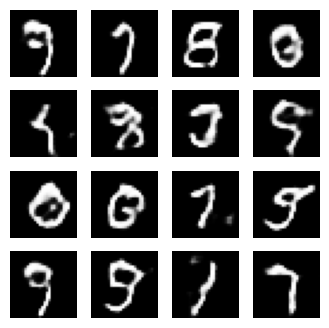

In [23]:
train(train_dataset, EPOCHS)

Restore the latest checkpoint.

In [24]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Create a GIF


In [25]:
# Display a single image using the epoch number
def display_image(epoch_no):
  return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

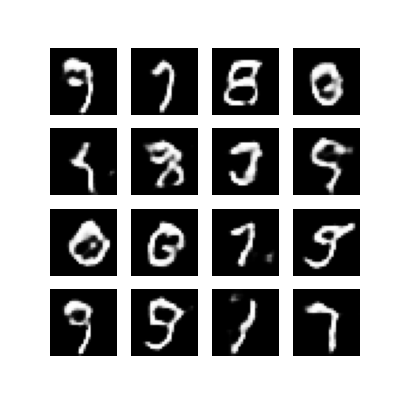

In [26]:
display_image(EPOCHS)

Use `imageio` to create an animated gif using the images saved during training.

In [27]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)

/tmp/ipykernel_1271/1982054950.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
/tmp/ipykernel_1271/1982054950.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)



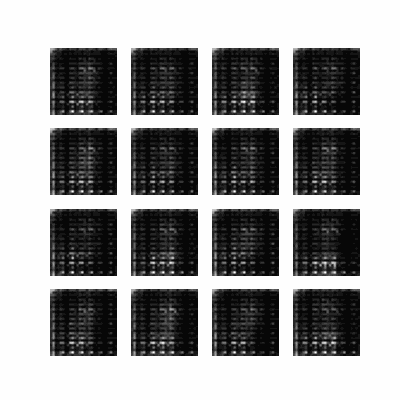

In [28]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)

## Next steps


This tutorial has shown the complete code necessary to write and train a GAN. As a next step, you might like to experiment with a different dataset, for example the Large-scale Celeb Faces Attributes (CelebA) dataset [available on Kaggle](https://www.kaggle.com/jessicali9530/celeba-dataset). To learn more about GANs see the [NIPS 2016 Tutorial: Generative Adversarial Networks](https://arxiv.org/abs/1701.00160).


TASK 1: DIFFERENT PARAMETERS, ARCHITECTURE

In [29]:
def show_generated(generator, noise_dim, title):
    seed = tf.random.normal([16, noise_dim])
    generated = generator(seed, training=False)
    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(generated[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def train_timed(dataset, epochs):
    for epoch in range(epochs):
        epoch_start = time.time()
        for batch in dataset:
            train_step(batch)
        print(f'Epoch {epoch+1}/{epochs} — {time.time()-epoch_start:.1f}s')

results = {}

Epoch 1/50 — 16.1s
Epoch 2/50 — 12.4s
Epoch 3/50 — 12.4s
Epoch 4/50 — 12.3s
Epoch 5/50 — 12.3s
Epoch 6/50 — 12.3s
Epoch 7/50 — 12.3s
Epoch 8/50 — 12.3s
Epoch 9/50 — 12.4s
Epoch 10/50 — 12.4s
Epoch 11/50 — 12.4s
Epoch 12/50 — 12.3s
Epoch 13/50 — 12.3s
Epoch 14/50 — 12.3s
Epoch 15/50 — 12.3s
Epoch 16/50 — 12.3s
Epoch 17/50 — 12.3s
Epoch 18/50 — 12.3s
Epoch 19/50 — 12.3s
Epoch 20/50 — 12.3s
Epoch 21/50 — 12.3s
Epoch 22/50 — 12.3s
Epoch 23/50 — 12.3s
Epoch 24/50 — 12.3s
Epoch 25/50 — 12.3s
Epoch 26/50 — 12.3s
Epoch 27/50 — 12.3s
Epoch 28/50 — 12.3s
Epoch 29/50 — 12.3s
Epoch 30/50 — 12.3s
Epoch 31/50 — 12.3s
Epoch 32/50 — 12.3s
Epoch 33/50 — 12.3s
Epoch 34/50 — 12.3s
Epoch 35/50 — 12.3s
Epoch 36/50 — 12.3s
Epoch 37/50 — 12.3s
Epoch 38/50 — 12.3s
Epoch 39/50 — 12.3s
Epoch 40/50 — 12.3s
Epoch 41/50 — 12.3s
Epoch 42/50 — 12.3s
Epoch 43/50 — 12.3s
Epoch 44/50 — 12.3s
Epoch 45/50 — 12.3s
Epoch 46/50 — 12.3s
Epoch 47/50 — 12.3s
Epoch 48/50 — 12.3s
Epoch 49/50 — 12.3s
Epoch 50/50 — 12.3s


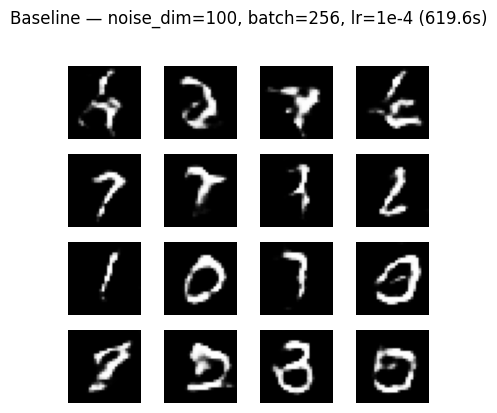

In [30]:
#BASELINE
noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model()
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images  = generator(noise, training=True)
        real_output  = discriminator(images, training=True)
        fake_output  = discriminator(fake_images, training=True)
        gen_loss     = generator_loss(fake_output)
        disc_loss    = discriminator_loss(real_output, fake_output)
    gen_grads  = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['Baseline'] = elapsed
show_generated(generator, noise_dim, f'Baseline — noise_dim=100, batch=256, lr=1e-4 ({elapsed}s)')


Epoch 1/100 — 16.1s
Epoch 2/100 — 12.3s
Epoch 3/100 — 12.4s
Epoch 4/100 — 12.4s
Epoch 5/100 — 12.3s
Epoch 6/100 — 12.3s
Epoch 7/100 — 12.3s
Epoch 8/100 — 12.3s
Epoch 9/100 — 12.3s
Epoch 10/100 — 12.3s
Epoch 11/100 — 12.3s
Epoch 12/100 — 12.3s
Epoch 13/100 — 12.3s
Epoch 14/100 — 12.3s
Epoch 15/100 — 12.3s
Epoch 16/100 — 12.3s
Epoch 17/100 — 12.3s
Epoch 18/100 — 12.3s
Epoch 19/100 — 12.3s
Epoch 20/100 — 12.3s
Epoch 21/100 — 12.3s
Epoch 22/100 — 12.3s
Epoch 23/100 — 12.3s
Epoch 24/100 — 12.3s
Epoch 25/100 — 12.3s
Epoch 26/100 — 12.3s
Epoch 27/100 — 12.3s
Epoch 28/100 — 12.3s
Epoch 29/100 — 12.3s
Epoch 30/100 — 12.3s
Epoch 31/100 — 12.3s
Epoch 32/100 — 12.3s
Epoch 33/100 — 12.3s
Epoch 34/100 — 12.3s
Epoch 35/100 — 12.4s
Epoch 36/100 — 12.3s
Epoch 37/100 — 12.3s
Epoch 38/100 — 12.3s
Epoch 39/100 — 12.3s
Epoch 40/100 — 12.3s
Epoch 41/100 — 12.3s
Epoch 42/100 — 12.3s
Epoch 43/100 — 12.3s
Epoch 44/100 — 12.3s
Epoch 45/100 — 12.3s
Epoch 46/100 — 12.3s
Epoch 47/100 — 12.3s
Epoch 48/100 — 12.3s
E

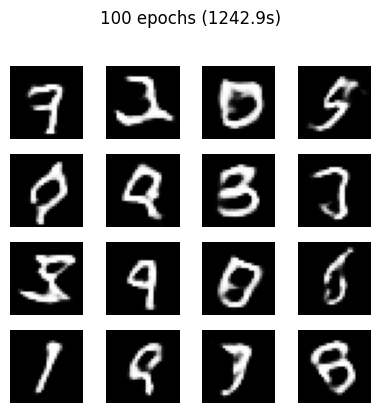

In [31]:
#100 epochs
noise_dim = 100
EPOCHS = 100
BATCH_SIZE = 256

generator = make_generator_model()
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images  = generator(noise, training=True)
        real_output  = discriminator(images, training=True)
        fake_output  = discriminator(fake_images, training=True)
        gen_loss     = generator_loss(fake_output)
        disc_loss    = discriminator_loss(real_output, fake_output)
    gen_grads  = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['100 epochs'] = elapsed
show_generated(generator, noise_dim, f'100 epochs ({elapsed}s)')

Epoch 1/50 — 16.2s
Epoch 2/50 — 12.3s
Epoch 3/50 — 12.6s
Epoch 4/50 — 12.4s
Epoch 5/50 — 12.2s
Epoch 6/50 — 12.1s
Epoch 7/50 — 12.1s
Epoch 8/50 — 12.1s
Epoch 9/50 — 12.2s
Epoch 10/50 — 12.2s
Epoch 11/50 — 12.3s
Epoch 12/50 — 12.2s
Epoch 13/50 — 12.2s
Epoch 14/50 — 12.2s
Epoch 15/50 — 12.2s
Epoch 16/50 — 12.2s
Epoch 17/50 — 12.2s
Epoch 18/50 — 12.2s
Epoch 19/50 — 12.2s
Epoch 20/50 — 12.3s
Epoch 21/50 — 12.3s
Epoch 22/50 — 12.2s
Epoch 23/50 — 12.2s
Epoch 24/50 — 12.2s
Epoch 25/50 — 12.2s
Epoch 26/50 — 12.2s
Epoch 27/50 — 12.2s
Epoch 28/50 — 12.2s
Epoch 29/50 — 12.2s
Epoch 30/50 — 12.2s
Epoch 31/50 — 12.2s
Epoch 32/50 — 12.2s
Epoch 33/50 — 12.2s
Epoch 34/50 — 12.2s
Epoch 35/50 — 12.2s
Epoch 36/50 — 12.2s
Epoch 37/50 — 12.2s
Epoch 38/50 — 12.2s
Epoch 39/50 — 12.2s
Epoch 40/50 — 12.2s
Epoch 41/50 — 12.2s
Epoch 42/50 — 12.2s
Epoch 43/50 — 12.2s
Epoch 44/50 — 12.2s
Epoch 45/50 — 12.2s
Epoch 46/50 — 12.2s
Epoch 47/50 — 12.2s
Epoch 48/50 — 12.2s
Epoch 49/50 — 12.2s
Epoch 50/50 — 12.2s


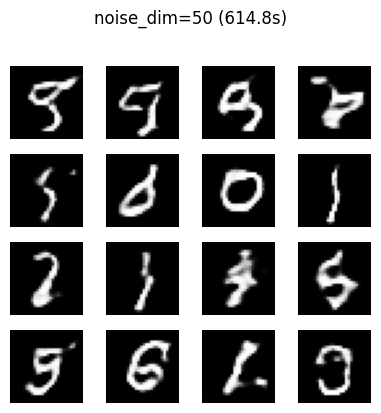

In [37]:

#NOISE DIM=50
noise_dim = 50
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model(noise_dim)
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['noise_dim=50'] = elapsed
show_generated(generator, noise_dim, f'noise_dim=50 ({elapsed}s)')

Epoch 1/50 — 15.9s
Epoch 2/50 — 12.5s
Epoch 3/50 — 12.5s
Epoch 4/50 — 12.5s
Epoch 5/50 — 12.5s
Epoch 6/50 — 12.5s
Epoch 7/50 — 12.5s
Epoch 8/50 — 12.5s
Epoch 9/50 — 12.5s
Epoch 10/50 — 12.5s
Epoch 11/50 — 12.5s
Epoch 12/50 — 20.5s
Epoch 13/50 — 12.5s
Epoch 14/50 — 12.7s
Epoch 15/50 — 12.7s
Epoch 16/50 — 12.5s
Epoch 17/50 — 12.4s
Epoch 18/50 — 12.4s
Epoch 19/50 — 12.4s
Epoch 20/50 — 12.5s
Epoch 21/50 — 12.5s
Epoch 22/50 — 12.5s
Epoch 23/50 — 12.5s
Epoch 24/50 — 12.5s
Epoch 25/50 — 12.5s
Epoch 26/50 — 12.5s
Epoch 27/50 — 12.5s
Epoch 28/50 — 12.5s
Epoch 29/50 — 12.5s
Epoch 30/50 — 12.5s
Epoch 31/50 — 12.5s
Epoch 32/50 — 12.5s
Epoch 33/50 — 12.5s
Epoch 34/50 — 12.5s
Epoch 35/50 — 12.5s
Epoch 36/50 — 12.5s
Epoch 37/50 — 12.5s
Epoch 38/50 — 12.5s
Epoch 39/50 — 12.5s
Epoch 40/50 — 12.5s
Epoch 41/50 — 12.5s
Epoch 42/50 — 12.5s
Epoch 43/50 — 12.5s
Epoch 44/50 — 12.5s
Epoch 45/50 — 12.5s
Epoch 46/50 — 12.5s
Epoch 47/50 — 12.5s
Epoch 48/50 — 12.5s
Epoch 49/50 — 12.5s
Epoch 50/50 — 12.5s


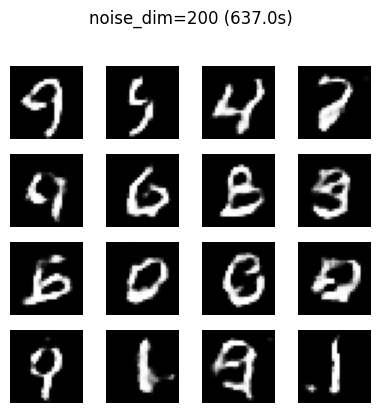

In [38]:
#NOISE_DIM = 200
noise_dim = 200
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model(noise_dim)
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['noise_dim=200'] = elapsed
show_generated(generator, noise_dim, f'noise_dim=200 ({elapsed}s)')

Epoch 1/50 — 16.7s
Epoch 2/50 — 12.3s
Epoch 3/50 — 12.3s
Epoch 4/50 — 12.4s
Epoch 5/50 — 12.3s
Epoch 6/50 — 12.3s
Epoch 7/50 — 12.3s
Epoch 8/50 — 12.3s
Epoch 9/50 — 20.5s
Epoch 10/50 — 12.3s
Epoch 11/50 — 12.5s
Epoch 12/50 — 12.6s
Epoch 13/50 — 12.3s
Epoch 14/50 — 12.3s
Epoch 15/50 — 12.2s
Epoch 16/50 — 12.2s
Epoch 17/50 — 12.2s
Epoch 18/50 — 12.3s
Epoch 19/50 — 12.4s
Epoch 20/50 — 12.4s
Epoch 21/50 — 12.4s
Epoch 22/50 — 12.3s
Epoch 23/50 — 12.3s
Epoch 24/50 — 12.3s
Epoch 25/50 — 12.3s
Epoch 26/50 — 12.3s
Epoch 27/50 — 12.3s
Epoch 28/50 — 12.3s
Epoch 29/50 — 12.3s
Epoch 30/50 — 12.3s
Epoch 31/50 — 12.3s
Epoch 32/50 — 12.3s
Epoch 33/50 — 12.3s
Epoch 34/50 — 12.3s
Epoch 35/50 — 12.3s
Epoch 36/50 — 12.3s
Epoch 37/50 — 12.3s
Epoch 38/50 — 12.3s
Epoch 39/50 — 12.3s
Epoch 40/50 — 12.4s
Epoch 41/50 — 12.4s
Epoch 42/50 — 12.3s
Epoch 43/50 — 12.3s
Epoch 44/50 — 12.3s
Epoch 45/50 — 12.3s
Epoch 46/50 — 12.3s
Epoch 47/50 — 12.3s
Epoch 48/50 — 12.3s
Epoch 49/50 — 12.3s
Epoch 50/50 — 12.3s


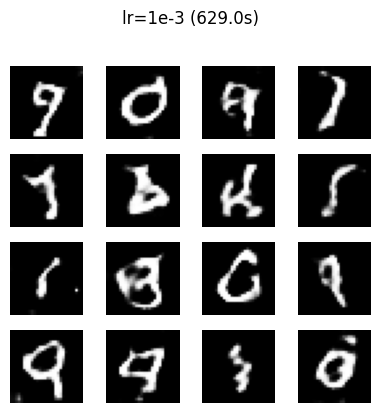

In [39]:

#lr=1e-3
noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model()
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-3)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['lr=1e-3'] = elapsed
show_generated(generator, noise_dim, f'lr=1e-3 ({elapsed}s)')

Epoch 1/50 — 17.1s
Epoch 2/50 — 11.9s
Epoch 3/50 — 11.9s
Epoch 4/50 — 11.9s
Epoch 5/50 — 11.9s
Epoch 6/50 — 11.9s
Epoch 7/50 — 11.9s
Epoch 8/50 — 11.9s
Epoch 9/50 — 11.9s
Epoch 10/50 — 11.9s
Epoch 11/50 — 11.9s
Epoch 12/50 — 11.9s
Epoch 13/50 — 11.9s
Epoch 14/50 — 11.9s
Epoch 15/50 — 11.9s
Epoch 16/50 — 11.9s
Epoch 17/50 — 11.9s
Epoch 18/50 — 11.9s
Epoch 19/50 — 11.9s
Epoch 20/50 — 11.9s
Epoch 21/50 — 12.0s
Epoch 22/50 — 12.0s
Epoch 23/50 — 11.9s
Epoch 24/50 — 11.9s
Epoch 25/50 — 11.9s
Epoch 26/50 — 11.9s
Epoch 27/50 — 11.9s
Epoch 28/50 — 11.9s
Epoch 29/50 — 11.9s
Epoch 30/50 — 11.9s
Epoch 31/50 — 11.9s
Epoch 32/50 — 11.9s
Epoch 33/50 — 11.9s
Epoch 34/50 — 11.9s
Epoch 35/50 — 11.9s
Epoch 36/50 — 11.9s
Epoch 37/50 — 11.9s
Epoch 38/50 — 11.9s
Epoch 39/50 — 11.9s
Epoch 40/50 — 11.9s
Epoch 41/50 — 11.9s
Epoch 42/50 — 11.9s
Epoch 43/50 — 11.9s
Epoch 44/50 — 11.9s
Epoch 45/50 — 12.0s
Epoch 46/50 — 11.9s
Epoch 47/50 — 11.9s
Epoch 48/50 — 11.9s
Epoch 49/50 — 11.9s
Epoch 50/50 — 11.9s


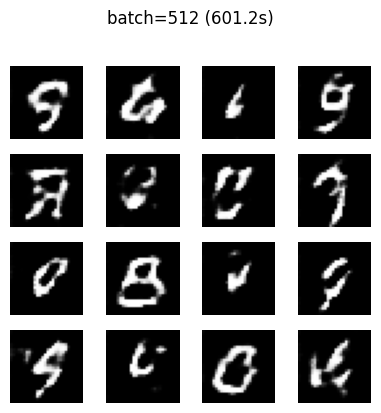

In [40]:

#BATCH_SIZE=512
noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 512

train_dataset_512 = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

generator = make_generator_model()
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset_512, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['batch=512'] = elapsed
show_generated(generator, noise_dim, f'batch=512 ({elapsed}s)')

Epoch 1/50 — 12.8s
Epoch 2/50 — 8.4s
Epoch 3/50 — 8.5s
Epoch 4/50 — 8.5s
Epoch 5/50 — 8.5s
Epoch 6/50 — 8.5s
Epoch 7/50 — 8.4s
Epoch 8/50 — 8.4s
Epoch 9/50 — 8.4s
Epoch 10/50 — 8.4s
Epoch 11/50 — 8.4s
Epoch 12/50 — 8.4s
Epoch 13/50 — 8.4s
Epoch 14/50 — 8.5s
Epoch 15/50 — 8.4s
Epoch 16/50 — 8.4s
Epoch 17/50 — 8.4s
Epoch 18/50 — 8.4s
Epoch 19/50 — 8.4s
Epoch 20/50 — 8.4s
Epoch 21/50 — 8.5s
Epoch 22/50 — 8.4s
Epoch 23/50 — 8.4s
Epoch 24/50 — 8.4s
Epoch 25/50 — 8.4s
Epoch 26/50 — 8.4s
Epoch 27/50 — 8.4s
Epoch 28/50 — 8.4s
Epoch 29/50 — 8.4s
Epoch 30/50 — 8.4s
Epoch 31/50 — 8.4s
Epoch 32/50 — 8.4s
Epoch 33/50 — 8.4s
Epoch 34/50 — 8.4s
Epoch 35/50 — 8.4s
Epoch 36/50 — 8.4s
Epoch 37/50 — 8.4s
Epoch 38/50 — 8.4s
Epoch 39/50 — 8.5s
Epoch 40/50 — 8.4s
Epoch 41/50 — 8.4s
Epoch 42/50 — 8.5s
Epoch 43/50 — 8.5s
Epoch 44/50 — 8.4s
Epoch 45/50 — 8.4s
Epoch 46/50 — 8.4s
Epoch 47/50 — 8.4s
Epoch 48/50 — 8.4s
Epoch 49/50 — 8.4s
Epoch 50/50 — 8.4s


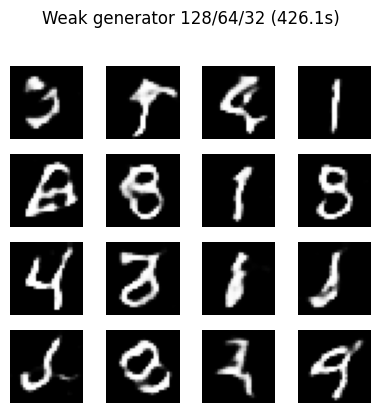

In [41]:

#Weaker generator (128/64/32 filters)
def make_generator_model_weak():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*128, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 128)))

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model_weak()
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['weak generator'] = elapsed
show_generated(generator, noise_dim, f'Weak generator 128/64/32 ({elapsed}s)')

Epoch 1/50 — 28.0s
Epoch 2/50 — 23.2s
Epoch 3/50 — 23.0s
Epoch 4/50 — 23.0s
Epoch 5/50 — 23.1s
Epoch 6/50 — 23.1s
Epoch 7/50 — 23.2s
Epoch 8/50 — 23.0s
Epoch 9/50 — 23.0s
Epoch 10/50 — 23.1s
Epoch 11/50 — 23.0s
Epoch 12/50 — 23.1s
Epoch 13/50 — 23.1s
Epoch 14/50 — 23.1s
Epoch 15/50 — 23.1s
Epoch 16/50 — 23.0s
Epoch 17/50 — 23.0s
Epoch 18/50 — 23.1s
Epoch 19/50 — 23.1s
Epoch 20/50 — 23.1s
Epoch 21/50 — 23.1s
Epoch 22/50 — 23.1s
Epoch 23/50 — 23.1s
Epoch 24/50 — 23.1s
Epoch 25/50 — 23.1s
Epoch 26/50 — 23.1s
Epoch 27/50 — 23.1s
Epoch 28/50 — 23.1s
Epoch 29/50 — 23.1s
Epoch 30/50 — 23.1s
Epoch 31/50 — 23.1s
Epoch 32/50 — 23.0s
Epoch 33/50 — 23.1s
Epoch 34/50 — 23.1s
Epoch 35/50 — 23.0s
Epoch 36/50 — 23.0s
Epoch 37/50 — 23.0s
Epoch 38/50 — 23.1s
Epoch 39/50 — 23.1s
Epoch 40/50 — 23.1s
Epoch 41/50 — 23.0s
Epoch 42/50 — 22.9s
Epoch 43/50 — 23.1s
Epoch 44/50 — 23.1s
Epoch 45/50 — 23.0s
Epoch 46/50 — 23.1s
Epoch 47/50 — 23.1s
Epoch 48/50 — 23.1s
Epoch 49/50 — 23.1s
Epoch 50/50 — 23.0s


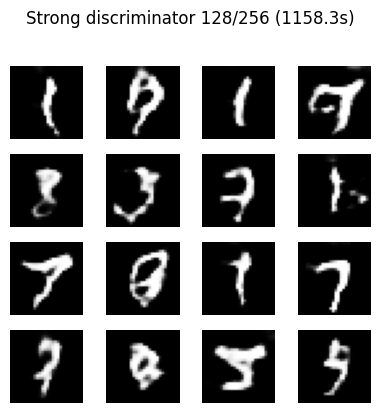

In [42]:

#Stronger discriminator (125/256 filters)
def make_discriminator_model_strong():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model()
discriminator = make_discriminator_model_strong()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['strong discriminator'] = elapsed
show_generated(generator, noise_dim, f'Strong discriminator 128/256 ({elapsed}s)')


Epoch 1/150 — 38.6s
Epoch 2/150 — 32.9s
Epoch 3/150 — 32.9s
Epoch 4/150 — 32.6s
Epoch 5/150 — 32.5s
Epoch 6/150 — 32.5s
Epoch 7/150 — 32.6s
Epoch 8/150 — 32.7s
Epoch 9/150 — 32.6s
Epoch 10/150 — 32.7s
Epoch 11/150 — 32.7s
Epoch 12/150 — 32.8s
Epoch 13/150 — 32.7s
Epoch 14/150 — 32.8s
Epoch 15/150 — 32.7s
Epoch 16/150 — 32.8s
Epoch 17/150 — 32.8s
Epoch 18/150 — 32.8s
Epoch 19/150 — 32.8s
Epoch 20/150 — 32.8s
Epoch 21/150 — 32.8s
Epoch 22/150 — 32.7s
Epoch 23/150 — 32.7s
Epoch 24/150 — 32.6s
Epoch 25/150 — 32.7s
Epoch 26/150 — 32.6s
Epoch 27/150 — 32.6s
Epoch 28/150 — 32.6s
Epoch 29/150 — 32.8s
Epoch 30/150 — 32.7s
Epoch 31/150 — 32.7s
Epoch 32/150 — 32.7s
Epoch 33/150 — 32.9s
Epoch 34/150 — 32.8s
Epoch 35/150 — 32.7s
Epoch 36/150 — 32.7s
Epoch 37/150 — 32.6s
Epoch 38/150 — 32.6s
Epoch 39/150 — 32.5s
Epoch 40/150 — 32.6s
Epoch 41/150 — 32.5s
Epoch 42/150 — 32.7s
Epoch 43/150 — 32.7s
Epoch 44/150 — 33.0s
Epoch 45/150 — 32.8s
Epoch 46/150 — 32.8s
Epoch 47/150 — 32.7s
Epoch 48/150 — 32.6s
E

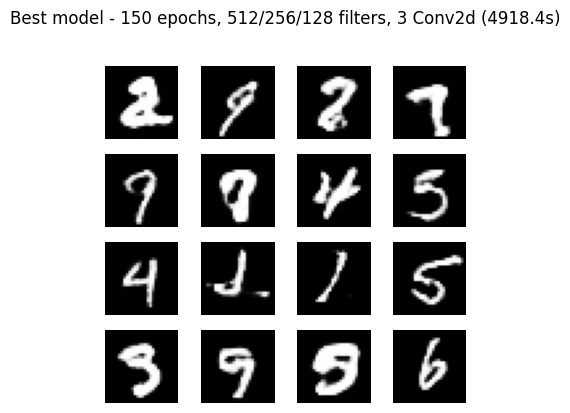

In [43]:

def make_generator_best(noise_dim=100):
    model = tf.keras.Sequential()
    model.add(layers.Dense(7*7*512, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 512)))

    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

def make_discriminator_best():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(1, 1), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

noise_dim = 100
EPOCHS = 150
BATCH_SIZE = 256

generator = make_generator_best(noise_dim=noise_dim)
discriminator = make_discriminator_best()
generator_optimizer = tf.keras.optimizers.Adam(2e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset, EPOCHS)
elapsed = round(time.time() - t0, 1)

results['best model'] = elapsed
show_generated(generator, noise_dim, f'Best model - 150 epochs, 512/256/128 filters, 3 Conv2d ({elapsed}s)')

In [44]:

for name, t in results.items():
    print(f'{name:25s} -> {t}s')


Baseline                  -> 619.6s
100 epochs                -> 1242.9s
noise_dim=50              -> 614.8s
noise_dim=200             -> 637.0s
lr=1e-3                   -> 629.0s
batch=512                 -> 601.2s
weak generator            -> 426.1s
strong discriminator      -> 1158.3s
best model                -> 4918.4s


TASK 2: FASHION MNIST & RGB

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50 — 15.9s
Epoch 2/50 — 12.4s
Epoch 3/50 — 12.4s
Epoch 4/50 — 12.4s
Epoch 5/50 — 12.3s
Epoch 6/50 — 12.3s
Epoch 7/50 — 12.3s
Epoch 8/50 — 12.3s
Epoch 9/50 — 12.3s
Epoch 10/50 — 12.3s
Epoch 11/50 — 12.3s
Epoch 12/50 — 12.3s
Epoch 13/50 — 12.3s
Epoch 14/50 — 12.3s
Epoch 15/50 — 12.3s
Epoch 16/50 — 12.3s
Epoch 17/50 — 12.3s
Epoch 18/50 — 12.3s
Epoch 19/50 — 12.3s
Epoch 20/50 — 12.3s
Epoch 21/50 — 12.3s
Epoch 22/50 — 12.3s
Epoch 23/50 — 12.3s
Epoch 24/50 — 12.3s
Epoch 25/50 — 12.3s
Epoch 26/50 — 12.3s
Epoch 27/50 — 12.3s
Epoch 28/50 — 12.3s
Epoch 29/50 — 12.3s
Epoch 30/50 — 12.3s
Epoch 31/50 — 12.3s
Epoch 32/50 — 12.3s
Epoch 33/50 — 12.3s
Epoch 34/50 — 12.3s
Epoch 35/50 — 12.3s
Epoch 36/50 — 12.3s
Epoch 37/50 — 12.3s
Epoch 38/50 — 12.3s
Epoch 39/50 — 12.3s
Epoch 40/50 — 12.3s
Epoch 41/50 — 12.3s
E

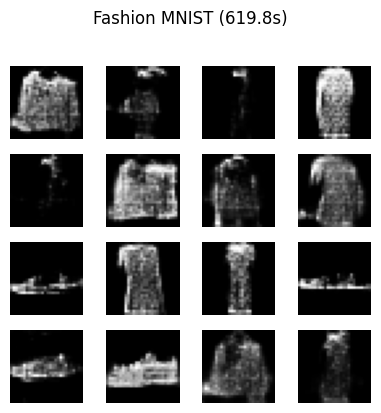

In [45]:
#FASHION MNIST
(train_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

train_dataset_fashion = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_model(noise_dim=noise_dim)
discriminator = make_discriminator_model()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset_fashion, EPOCHS)
elapsed = round(time.time() - t0, 1)

print(f'Fashion MNIST total: {elapsed}s')
show_generated(generator, noise_dim, f'Fashion MNIST ({elapsed}s)')

In [3]:
#RGB

(train_images_rgb, _), (_, _) = tf.keras.datasets.cifar10.load_data()
train_images_rgb = train_images_rgb.astype('float32')
train_images_rgb = (train_images_rgb - 127.5) / 127.5

train_dataset_rgb = tf.data.Dataset.from_tensor_slices(train_images_rgb).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f'Dataset shape: {train_images_rgb.shape}')  # (50000, 32, 32, 3)

NameError: name 'tf' is not defined

In [1]:
# generator for 32x32 RGB
def make_generator_rgb(noise_dim=100):
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

# discriminator for 32x32 RGB
def make_discriminator_rgb():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

# show RGB generated images
def show_generated_rgb(generator, noise_dim, title):
    seed = tf.random.normal([16, noise_dim])
    generated = generator(seed, training=False)
    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        img = generated[i] * 127.5 + 127.5
        plt.imshow(img.numpy().astype('uint8'))
        plt.axis('off')
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

In [2]:

noise_dim = 100
EPOCHS = 50
BATCH_SIZE = 256

generator = make_generator_rgb(noise_dim=noise_dim)
discriminator = make_discriminator_rgb()
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

t0 = time.time()
train_timed(train_dataset_rgb, EPOCHS)
elapsed = round(time.time() - t0, 1)

print(f'RGB CIFAR-10 total: {elapsed}s')
show_generated_rgb(generator, noise_dim, f'RGB CIFAR-10 ({elapsed}s)')

NameError: name 'tf' is not defined